In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv("telecom_churn_data.csv")

In [3]:
df.columns

Index(['customerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.head()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.shape

(7043, 21)

In [7]:
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


<Axes: ylabel='Gender'>

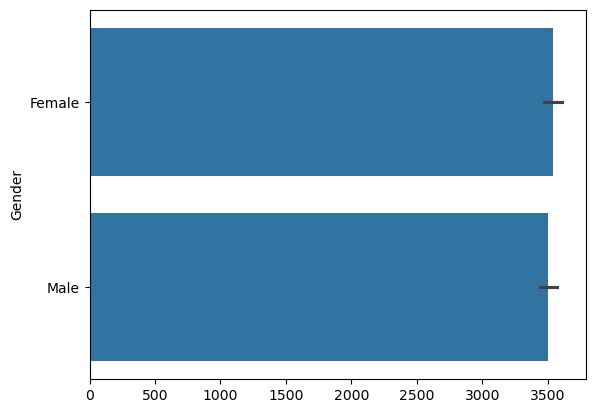

In [8]:
sns.barplot(df['Gender'])

<Axes: xlabel='SeniorCitizen', ylabel='count'>

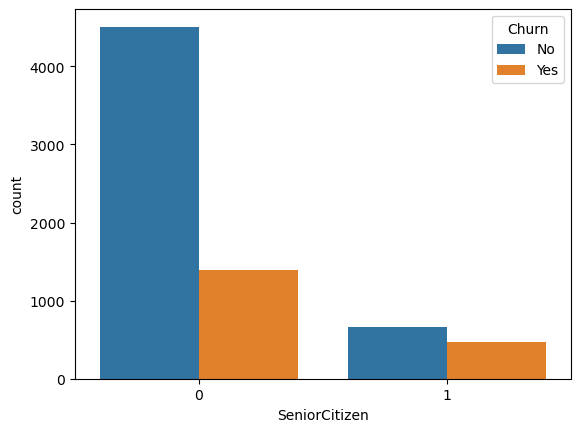

In [9]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

In [10]:
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')
ct

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


<Axes: xlabel='SeniorCitizen'>

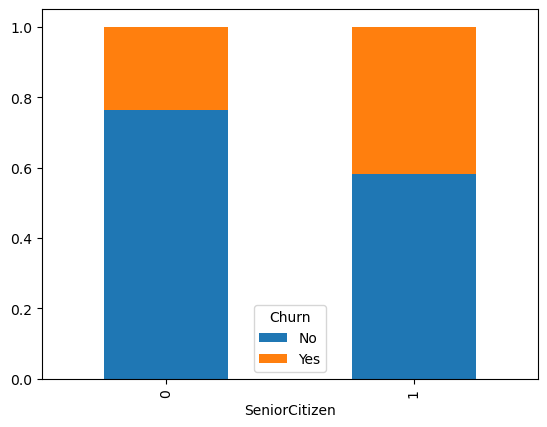

In [11]:
ct.plot(kind='bar', stacked=True)

<Axes: xlabel='Partner', ylabel='count'>

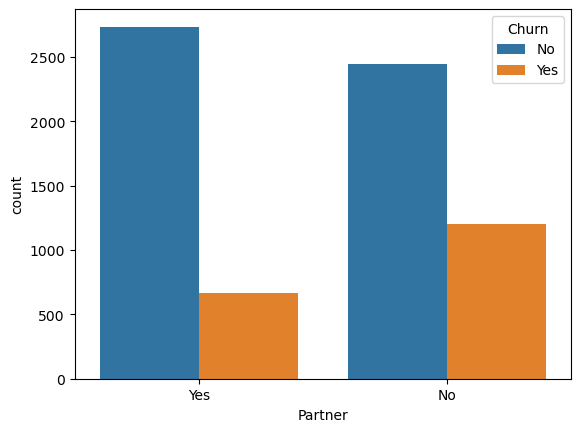

In [12]:
sns.countplot(x='Partner', hue='Churn', data=df)

In [13]:
ct = pd.crosstab(df['Partner'], df['Churn'], normalize='index')
ct

Churn,No,Yes
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649


<Axes: xlabel='Partner'>

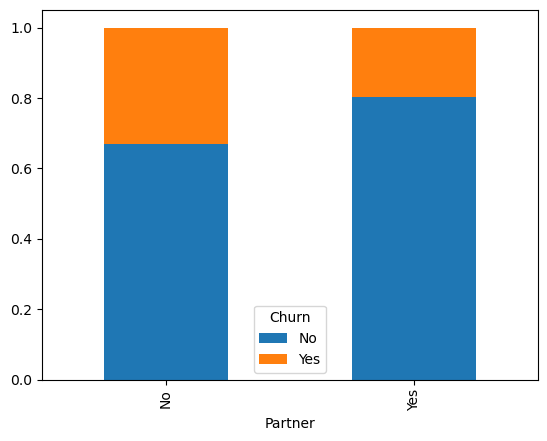

In [14]:
ct.plot(kind = "bar",stacked = True)

#“Using normalized crosstab analysis, I observed that customers without partners exhibit a higher churn rate, 
suggesting that relationship status is an important factor in customer retention.”

In [15]:
pd.crosstab(df['Dependents'] , df['Churn'] ,normalize= 'index' )

Churn,No,Yes
Dependents,,
No,0.687209,0.312791
Yes,0.845498,0.154502


In [16]:
# drop customerID columns beacause it is not show realtion with churn

In [17]:
df.drop(columns='customerID',inplace=True)

<Axes: xlabel='Tenure', ylabel='Count'>

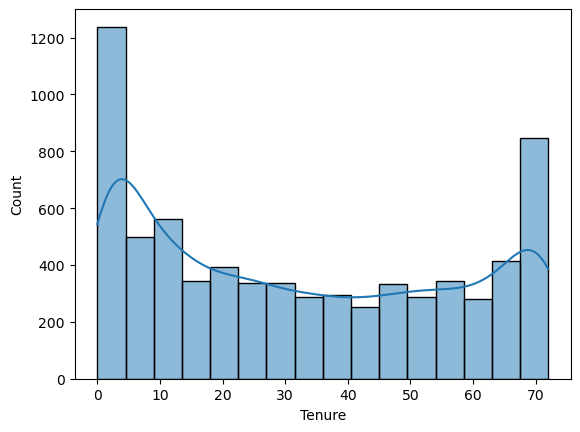

In [18]:
sns.histplot(df['Tenure'],kde = True)

<Axes: xlabel='Churn', ylabel='Tenure'>

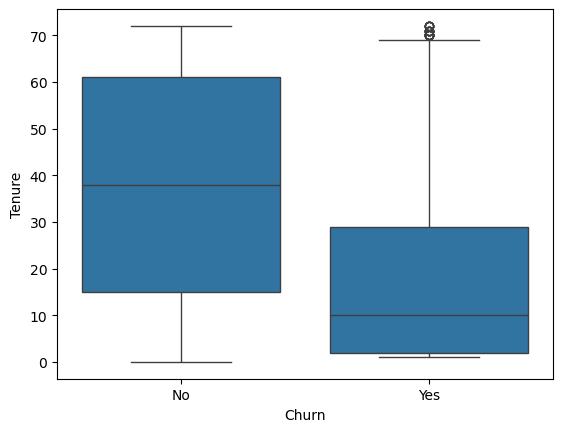

In [19]:
sns.boxplot(x='Churn', y='Tenure', data=df)

In [20]:
def crosstab(x):
    return pd.crosstab(df[x],df['Churn'],normalize='index')

In [21]:
crosstab('Partner')

Churn,No,Yes
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649


In [22]:
crosstab('PhoneService')

Churn,No,Yes
PhoneService,,
No,0.750733,0.249267
Yes,0.732904,0.267096


In [23]:
from scipy.stats import chi2_contingency

def chi_square_test(df, column, target='Churn'):
    # Create contingency table
    ct = pd.crosstab(df[column], df[target])
    
    # Perform chi-square test
    chi2, p, dof, expected = chi2_contingency(ct)
    
    print(f"Column: {column}")
    print(f"Chi2 Value: {chi2}")
    print(f"P-value: {p}")
    
    # Interpretation
    if p < 0.05:
        print("Result: Significant relationship ✅")
    else:
        print("Result: No significant relationship ❌ and drop this columns")

In [24]:
chi_square_test(df,'PhoneService',target='Churn')

Column: PhoneService
Chi2 Value: 0.9150329892546948
P-value: 0.3387825358066928
Result: No significant relationship ❌ and drop this columns


In [25]:
df.drop(['PhoneService'] , axis=1,inplace = True)

#multiplelines columns

In [26]:
crosstab('MultipleLines')

Churn,No,Yes
MultipleLines,,
No,0.749754,0.250246
Yes,0.713901,0.286099


In [27]:
chi_square_test(df,'MultipleLines',target='Churn')

Column: MultipleLines
Chi2 Value: 11.143251001456251
P-value: 0.0008433795342472428
Result: Significant relationship ✅


In [28]:
crosstab('InternetService')

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [29]:
cols = ['OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

In [30]:
for i in cols :
    chi_square_test(df,i,target='Churn')
    

Column: OnlineSecurity
Chi2 Value: 205.63310416062058
P-value: 1.2320984831180024e-46
Result: Significant relationship ✅
Column: OnlineBackup
Chi2 Value: 47.260854003612764
P-value: 6.214092807254819e-12
Result: Significant relationship ✅
Column: DeviceProtection
Chi2 Value: 30.513394539261306
P-value: 3.315693222362861e-08
Result: Significant relationship ✅
Column: TechSupport
Chi2 Value: 190.16684201526067
P-value: 2.9235674453140758e-43
Result: Significant relationship ✅
Column: StreamingTV
Chi2 Value: 27.862522274233417
P-value: 1.3024835736732686e-07
Result: Significant relationship ✅
Column: StreamingMovies
Chi2 Value: 26.25133601003847
P-value: 2.9974738476267514e-07
Result: Significant relationship ✅


In [31]:
results = []

for col in cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(ct)
    
    results.append({
        'Feature': col,
        'Chi2': chi2,
        'p-value': p,
        'Significance': 'Significant keep feature' if p < 0.05 else 'Not Significant'
    })

chi_df = pd.DataFrame(results).sort_values(by='p-value')
chi_df['p-value'] = chi_df['p-value'].round(6)
chi_df

,Feature,Chi2,p-value,Significance
0,OnlineSecurity,205.633104,0.0,Significant keep feature
3,TechSupport,190.166842,0.0,Significant keep feature
1,OnlineBackup,47.260854,0.0,Significant keep feature
2,DeviceProtection,30.513395,0.0,Significant keep feature
4,StreamingTV,27.862522,0.0,Significant keep feature
5,StreamingMovies,26.251336,0.0,Significant keep feature


In [32]:
def countplot(x):
    return sns.countplot(x = df[x],hue=df['Churn'])

<Axes: xlabel='Contract', ylabel='count'>

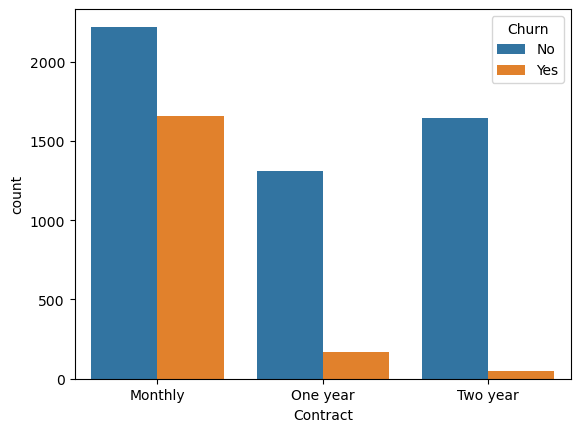

In [33]:
countplot("Contract")

In [34]:
crosstab('Contract')

Churn,No,Yes
Contract,,
Monthly,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


<Axes: xlabel='PaperlessBilling', ylabel='count'>

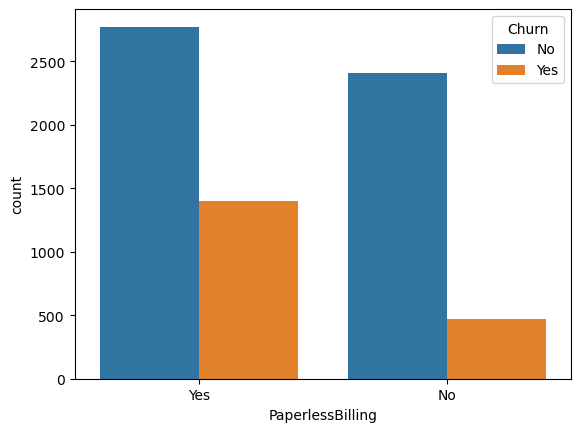

In [35]:
countplot('PaperlessBilling')

<Axes: xlabel='PaymentMethod', ylabel='count'>

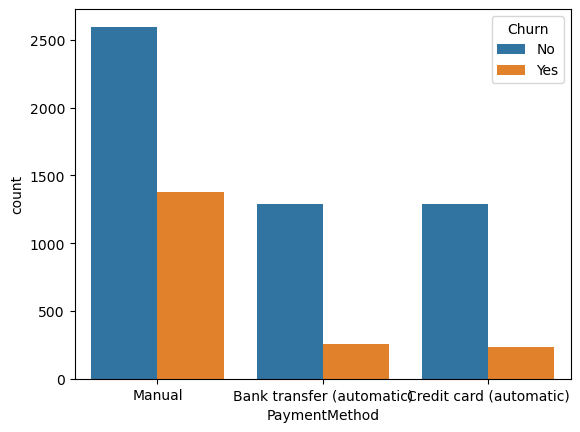

In [36]:
countplot('PaymentMethod')

In [37]:
crosstab('PaymentMethod')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Manual,0.653256,0.346744


#  data preprocessing

In [38]:
#  lable encoding

In [39]:
df = pd.get_dummies(data = df,columns = ['InternetService','Contract'])

In [40]:
df = pd.get_dummies(data = df,columns = ['Gender'])

In [41]:
df = pd.get_dummies(data = df,columns = ['PaymentMethod'])

In [42]:
col = [ 'Partner', 'Dependents', 'MultipleLines',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

In [43]:
for i in col:
    df[i] = df[i].map({
        'Yes' :1,
        'No' :0,
    })

In [44]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'MultipleLines',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No', 'Contract_Monthly',
       'Contract_One year', 'Contract_Two year', 'Gender_Female',
       'Gender_Male', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Manual'],
      dtype='object')

In [45]:
df['MonthlyCharges'] = df['MonthlyCharges'].astype(float)

In [46]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')

In [47]:
df['Churn'] = df['Churn'].map({
    'Yes' :1,
    'No' :0,
})

In [48]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace = True)

<Axes: >

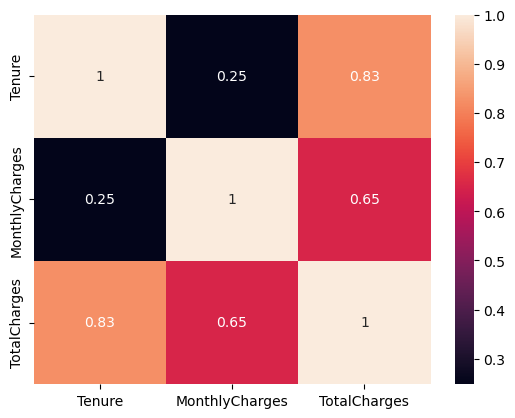

In [60]:
num_cols = ['Tenure','MonthlyCharges','TotalCharges']
sns.heatmap(data=df[num_cols].corr(), annot=True)

In [49]:
df = df.astype(int)

In [50]:
df.head()

,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,InternetService_Fiber optic,InternetService_No,Contract_Monthly,Contract_One year,Contract_Two year,Gender_Female,Gender_Male,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Manual
0,0,1,0,1,0,0,1,0,0,0,...,0,0,1,0,0,1,0,0,0,1
1,0,0,0,34,0,1,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1
2,0,0,0,2,0,1,1,0,0,0,...,0,0,1,0,0,0,1,0,0,1
3,0,0,0,45,0,1,0,1,1,0,...,0,0,0,1,0,0,1,1,0,0
4,0,0,0,2,0,0,0,0,0,0,...,1,0,1,0,0,1,0,0,0,1


In [51]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'MultipleLines',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No', 'Contract_Monthly',
       'Contract_One year', 'Contract_Two year', 'Gender_Female',
       'Gender_Male', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Manual'],
      dtype='object')

In [52]:
df.drop(columns=['Gender_Male'], inplace=True)  # keep Gender_Female

In [53]:
df.drop(columns=['Contract_Two year'], inplace=True)
df.drop(columns=['InternetService_No'], inplace=True)
df.drop(columns=['PaymentMethod_Manual'], inplace=True)

#  models

In [54]:
X = df.drop('Churn',axis=1)

In [55]:
y = df['Churn']

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#  XGBOOST

In [57]:
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    scale_pos_weight=2.76
)

In [ ]:
model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([1, 0, 0, ..., 1, 1, 0], shape=(2325,))

In [ ]:
from sklearn.metrics import classification_report , accuracy_score, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1697
           1       0.53      0.80      0.64       628

    accuracy                           0.76      2325
   macro avg       0.72      0.77      0.73      2325
weighted avg       0.81      0.76      0.77      2325



In [ ]:
accuracy_score(y_test,y_pred)

0.7578494623655914

In [ ]:
confusion_matrix(y_test,y_pred)

array([[1260,  437],
       [ 126,  502]])

In [ ]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [ ]:
# Grid search cv

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# grid_clf = GridSearchCV(model,{
#     # 'n_estimators': [200, 500, 1000],      # bigger trees for low lr
#     'max_depth': [3, 4, 5],
#     'learning_rate': [0.05, 0.1],          # drop 0.01 unless n_estimators is large
#     # 'scale_pos_weight': [2, 2.5, 3],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.8, 1.0]
# },cv = 5,scoring='f1')

In [ ]:
# accuracy_score(y_test,y_pred_new)

In [ ]:
# y_pred_new = grid_clf.predict(X_test)

In [ ]:
# confusion_matrix(y_test,y_pred_new)

In [ ]:
# print(classification_report(y_test,y_pred_new))

#  randomized search cv

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'scale_pos_weight': [2, 2.5, 3],# for imbalance
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=100,              
    scoring='f1',           
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [ ]:
y_pred_random  = random_search.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_random)

0.7763440860215054

In [ ]:
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 2.5, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best Score: 0.6244881579508047


In [ ]:
best_model = random_search.best_estimator_

y_pred_random = best_model.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_random)

0.7763440860215054

In [ ]:
print(classification_report(y_test, y_pred_random))

              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1697
           1       0.56      0.78      0.65       628

    accuracy                           0.78      2325
   macro avg       0.73      0.78      0.74      2325
weighted avg       0.81      0.78      0.79      2325



In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(y_test,y_pred_random)

array([[1317,  380],
       [ 140,  488]])

In [ ]:
import joblib
joblib.dump(best_model,'RandomizedXGBOOST.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']

In [ ]:
df2= pd.read_csv("telecom_churn_data.csv")

In [ ]:
df2.columns

Index(['customerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

#  new model

In [ ]:
param_list = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'scale_pos_weight': [2, 2.5, 3],
    'min_child_weight': [1, 3, 5],   # add this — helps with imbalance
    'gamma': [0, 0.1, 0.3]           # add this — controls tree pruning
}

In [ ]:
from sklearn.metrics import precision_recall_curve

probs = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
# pick threshold where F1 is maximized
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[f1_scores[:-1].argmax()]
y_pred_tuned = (probs >= best_threshold).astype(int)

In [ ]:
accuracy_score(y_test,y_pred_tuned)

0.7961290322580645

In [ ]:
print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1697
           1       0.60      0.73      0.66       628

    accuracy                           0.80      2325
   macro avg       0.75      0.77      0.76      2325
weighted avg       0.81      0.80      0.80      2325



In [ ]:
confusion_matrix(y_test,y_pred_tuned)

array([[1394,  303],
       [ 171,  457]])

#  Random forest 

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier


In [ ]:
base_learner = [
    ('dt',DecisionTreeClassifier(random_state=42)),
    ('svc',SVC(kernel = 'rbf',probability=True,random_state=42)),
    ('lr',LogisticRegression(random_state=42))
]

In [ ]:
meta_learner = XGBClassifier(scale_pos_weight = 2.70)

In [ ]:
stacking_classfier = StackingClassifier(
    estimators=base_learner,
    final_estimator=meta_learner,
    cv=5
)

In [ ]:
model_forest = stacking_classfier.fit(X_train,y_train)

In [ ]:
y_pred_forest = model_forest.predict(X_test)

In [ ]:
y_pred_forest

array([1, 0, 0, ..., 1, 1, 0], shape=(2325,))

In [ ]:
accuracy_score(y_test,y_pred_forest)

0.7518279569892473

In [ ]:
confusion_matrix(y_test,y_pred_forest)

array([[1309,  388],
       [ 189,  439]])

In [ ]:
print(classification_report(y_test,y_pred_forest))

              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1697
           1       0.53      0.70      0.60       628

    accuracy                           0.75      2325
   macro avg       0.70      0.74      0.71      2325
weighted avg       0.78      0.75      0.76      2325



In [ ]:
df['MonthlyCharges'].min()

np.int64(18)